In [209]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

import typing

In [ ]:
# Default parameters

N = 641
L = 100.0
cfl = 0.5
advection = 1.0
sigma = 0.8
max_time = 50.0

In [211]:
# Initial conditions

def gaussian_pulse(
        grid: np.typing.ArrayLike, center, width) -> np.typing.ArrayLike:
    return np.exp(-((grid - center) / width) ** 2)


def square_wave(
        grid: np.typing.ArrayLike, center, width) -> np.typing.ArrayLike:
    return np.where(np.abs(grid - center) <= width, 1.0, 0.0)


def sine_wave(
        grid: np.typing.ArrayLike, wavenumber: int) -> np.typing.ArrayLike:
    return np.sin(wavenumber * grid)


def left_triangle(grid: np.typing.ArrayLike, l1, l2) -> np.typing.ArrayLike:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = (grid[mask] - l1) / (l2 - l1)
    return result


def rectangle(grid: np.typing.ArrayLike, l1, l2) -> np.typing.ArrayLike:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = 1.0
    return result


def wave(grid: np.typing.ArrayLike, l1, l2) -> np.typing.ArrayLike:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = 0.5 * (1 - np.cos(2 * np.pi * (grid[mask] - l1) / (l2 - l1)))
    return result


def tooth(grid: np.typing.ArrayLike, l1, l2, l11, l22) -> np.typing.ArrayLike:
    result = np.zeros_like(grid)

    mask1 = (grid >= l1) & (grid < l11)
    result[mask1] = -(2/3) * (grid[mask1] - l1) / (l11 - l1) + 1

    mask2 = (grid >= l11) & (grid <= l22)
    result[mask2] = 1/3

    mask3 = (grid > l22) & (grid <= l2)
    result[mask3] = (2/3) * (grid[mask3] - l2) / (l2 - l22) + 1

    return result


def letter_m(grid: np.typing.ArrayLike, l1, l2, l12=None) -> np.typing.ArrayLike:
    l12 = l12 or (l1 + l2) / 2.0
    result = np.zeros_like(grid)

    mask1 = (grid >= l1) & (grid < l12)
    result[mask1] = -(2/3) * (grid[mask1] - l1) / (l12 - l1) + 1

    mask2 = (grid >= l12) & (grid <= l2)
    result[mask2] = (2/3) * (grid[mask2] - l2) / (l2 - l12) + 1

    return result


def right_triangle(grid: np.typing.ArrayLike, l1, l2) -> np.typing.ArrayLike:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = (l2 - grid[mask]) / (l2 - l1)
    return result

In [212]:
BoundaryType = typing.Literal['absorbing', 'periodic', 'fixed', 'extrapolation']

def apply_bc(
        u: np.typing.ArrayLike,
        advection: np.typing.ArrayLike = None,
        bc_type: BoundaryType = 'periodic') -> np.typing.ArrayLike:

    match bc_type:
        case 'absorbing':
            if advection > 0:
                u[0] = 0.0
                u[1] = 0.0
                u[-2] = u[-3]
                u[-1] = u[-2]
            else:
                u[-1] = 0.0
                u[-2] = 0.0
                u[1] = u[2]
                u[0] = u[1]
        case 'periodic':
            u[0] = u[-4]
            u[1] = u[-3]
            u[-2] = u[2]
            u[-1] = u[3]
        case 'fixed':
            u[0] = 0.0
            u[1] = 0.0
            u[-2] = 0.0
            u[-1] = 0.0
        case 'extrapolation':
            if advection > 0:
                u[0] = 0.0
                u[1] = 0.0
                u[-1] = 3.0 * u[-2] - 3.0 * u[-3] + u[-4]
                u[-2] = 3.0 * u[-3] - 3.0 * u[-4] + u[-5]
            else:
                u[-1] = 0.0
                u[-2] = 0.0
                u[0] = 3.0 * u[1] - 3.0 * u[2] + u[3]
                u[1] = 3.0 * u[2] - 3.0 * u[3] + u[4]

    return u

In [ ]:
def exact_solution(grid: npt.NDArray[np.floating], ic_func, ic_kwargs, advection, time, bc_type, L) -> npt.NDArray[np.floating]:
    shifted = grid - advection * time
    if bc_type == "periodic":
        shifted = shifted % L
    return ic_func(shifted, **ic_kwargs)

In [214]:
from mlf_method import mlf_method_stencil

# Reload for prototyping and interactivity
import importlib; import mlf_method; importlib.reload(mlf_method); # noqa: E702

In [ ]:
def rusanov_step(u: npt.NDArray[np.floating], i: npt.NDArray[np.floating], *, cfl: np.floating, **_) -> npt.NDArray[np.floating]:
    cfl2 = cfl * cfl
    cfl3 = cfl2 * cfl
    omega = (4.0 * cfl2 + 1.0) * (4.0 - cfl2) / 5.0

    u_new = np.zeros_like(u)
    u_new[i] = (
        u[i]
        - cfl / 12.0 * (-u[i+2] + 8.0*u[i+1] - 8.0*u[i-1] + u[i-2])
        + cfl2 / 8.0 * (u[i+2] - 2.0*u[i] + u[i-2])
        - cfl3 / 12.0 * (u[i+2] - 2.0*u[i+1] + 2.0*u[i-1] - u[i-2])
        - omega / 24.0 * (u[i+2] - 4.0*u[i+1] + 6.0*u[i] - 4.0*u[i-1] + u[i-2])
    )
    return u_new


def mlf_with_correction_step(
    u: npt.NDArray[np.floating], i: npt.NDArray[np.floating], *,
    sigma: np.floating, cfl: np.floating,
    advection: np.floating, dt: np.floating, dx: np.floating,
    **_,
) -> npt.NDArray[np.floating]:
    cfl2 = cfl * cfl

    u_new = mlf_method_stencil(u, i, sigma=sigma, cfl=cfl, advection=advection, dt=dt, dx=dx)

    # Fall back to lower-order scheme at non-smooth points (local extrema)
    oscillation = (u_new[i+1] - u_new[i]) * (u_new[i] - u_new[i-1]) < 0.0
    u_low = (
        sigma * u[i]
        + (1.0 - sigma) * 0.5 * (u[i+1] + u[i-1])
        - 0.5 * cfl * (u[i+1] - u[i-1])
        + 0.5 * cfl2 * (u[i+1] - 2.0 * u[i] + u[i-1])
    )
    u_new[i] = np.where(oscillation, u_low, u_new[i])

    return u_new

In [216]:
StepFunc = typing.Callable[[npt.NDArray[np.floating],
                            npt.NDArray[np.integer],
                            typing.Any],
                           npt.NDArray[np.floating]]

ICFunc = typing.Callable[[npt.NDArray[np.floating], typing.Any],
                         npt.NDArray[np.floating]]


def advect(
        step_func: StepFunc, N: int = N, L: np.floating = L, cfl: np.floating = cfl,
        advection: np.floating = advection, sigma: np.floating = sigma,
        max_time: np.floating = max_time, bc_type: BoundaryType = "absorbing",
        ic_func: ICFunc = gaussian_pulse,
        ic_kwargs: dict = {"center": 20.0, "width": 5.0},):
    dx = L / (N - 1.0)
    grid = np.linspace(0.0, (N - 1) * dx, N)

    time = 0.0

    u = ic_func(grid, **ic_kwargs)

    while time <= max_time:
        dt = dx * cfl / advection
        time += dt

        i = np.arange(2, N - 2)

        u = apply_bc(u)
        u = step_func(u, i, sigma=sigma, cfl=cfl,
                      dx=dx, advection=advection, dt=dt)

    u_exact = exact_solution(grid, ic_func, ic_kwargs,
                             advection, time, bc_type, L)

    return grid, u, u_exact

In [217]:
grid, u, u_exact = advect(mlf_method_stencil)
grid, u_rusanov, u_exact = advect(rusanov_step)

dx = L / (N - 1.0)

error_rusanov = np.abs(u_rusanov - u_exact)
error = np.abs(u - u_exact)


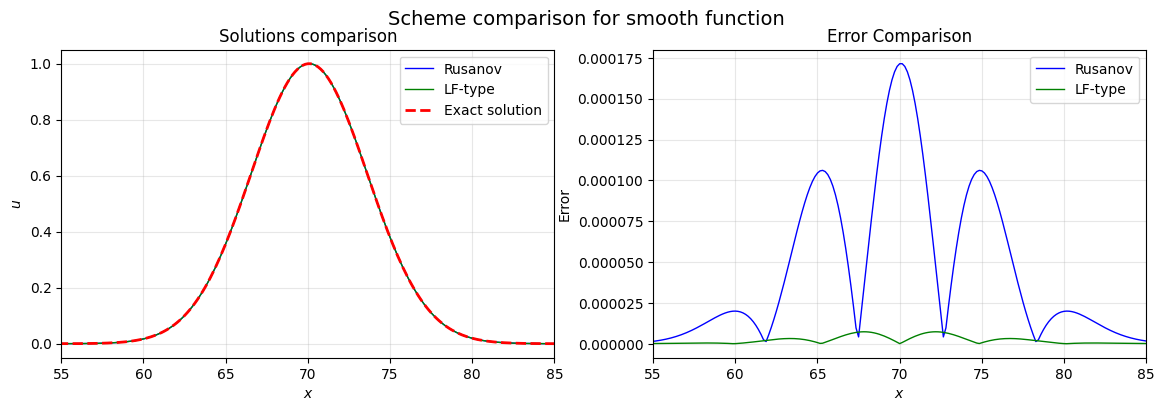

In [218]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(grid, u_rusanov, 'b-', linewidth=1, label='Rusanov')
plt.plot(grid, u, 'g-', linewidth=1, label='LF-type')
plt.plot(grid, u_exact, 'r--', linewidth=2, label='Exact solution')
plt.xlim(55, 85)
plt.xlabel('$x$')
plt.ylabel('$u$')
plt.title('Solutions comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Rusanov')
plt.plot(grid, error, 'g-', linewidth=1, label='LF-type')
plt.xlabel('$x$')
plt.xlim(55, 85)
plt.ylabel('Error')
plt.title('Error Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Scheme comparison for smooth function', fontsize=14)

plt.show()

In [219]:
errors_rusanov_Linf = []
errors_rusanov_L1 = []
errors_rusanov_L2 = []

errors_method_Linf = []
errors_method_L1 = []
errors_method_L2 = []

dxs = []

for N in [51, 101, 201, 401, 801, 1601]:
    dx = L / (N - 1.0)
    dxs.append(dx)

    grid, u, u_exact = advect(
        mlf_method_stencil,
        N=N,
        sigma=0.5,
        cfl=0.1,
        max_time=20,
        ic_func=gaussian_pulse,
        ic_kwargs={"center": 20.0, "width": 5.0},
    )
    grid, u_rusanov, u_exact = advect(
        rusanov_step,
        N=N,
        sigma=0.5,
        cfl=0.1,
        max_time=20,
        ic_func=gaussian_pulse,
        ic_kwargs={"center": 20.0, "width": 5.0},
    )

    err_rus = np.abs(u_rusanov - u_exact)
    errors_rusanov_Linf.append(np.max(err_rus))
    errors_rusanov_L1.append(np.mean(err_rus))
    errors_rusanov_L2.append(np.sqrt(np.mean(err_rus**2)))

    err = np.abs(u - u_exact)
    errors_method_Linf.append(np.max(err))
    errors_method_L1.append(np.mean(err))
    errors_method_L2.append(np.sqrt(np.mean(err**2)))

dxs = np.array(dxs)

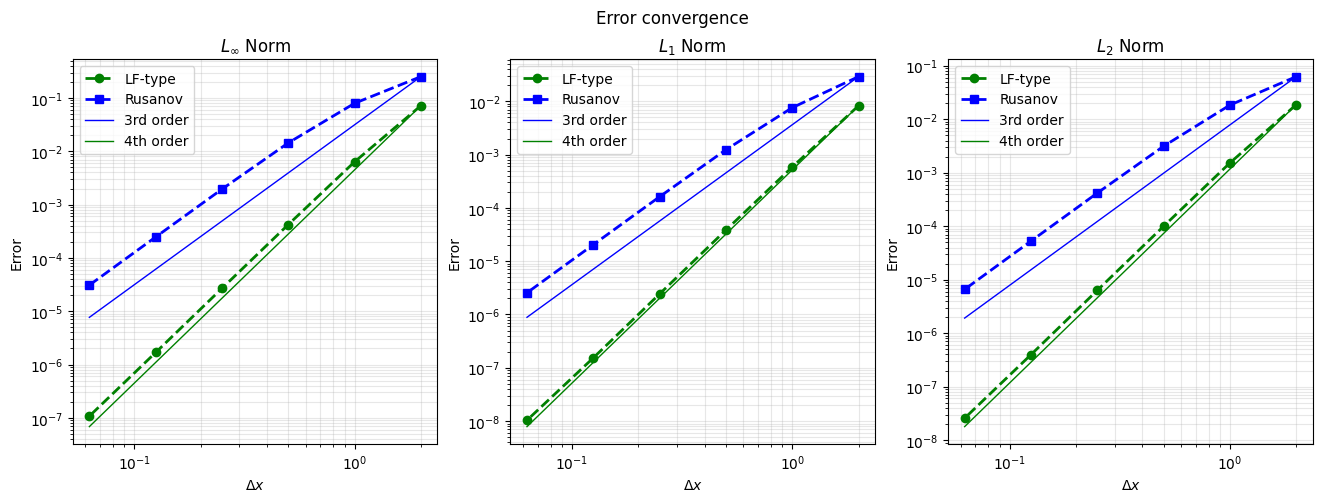

In [220]:
from matplotlib.axes import Axes


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
norm_names = ['$L_{\infty}$', '$L_1$', '$L_2$']
errors_method_all = [errors_method_Linf, errors_method_L1, errors_method_L2]
errors_rusanov_all = [errors_rusanov_Linf, errors_rusanov_L1, errors_rusanov_L2]

for ax, name, err_m, err_r in zip(axes, norm_names, errors_method_all, errors_rusanov_all):
    ax: Axes
    ax.loglog(dxs, err_m, 'go--', label='LF-type', linewidth=2)
    ax.loglog(dxs, err_r, 'bs--', label='Rusanov', linewidth=2)

    # Reference slopes
    slope = (dxs / dxs[0])
    # debug
    # for order in [1, 2, 3, 4, 5]:
        # ax.loglog(dxs, err_m[0] * slope**order, label=f"{order}-{'nd' if order < 2 else 'th'} order")

    ax.loglog(dxs, err_r[0] * slope**3, label='3rd order', color ='blue', linewidth=1)
    ax.loglog(dxs, err_m[0] * slope**4, label='4th order', color='green', linewidth=1)

    ax.set_xlabel(r'$\Delta x$')
    ax.set_ylabel('Error')
    ax.set_title(f'{name} Norm')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle("Error convergence")
plt.show()

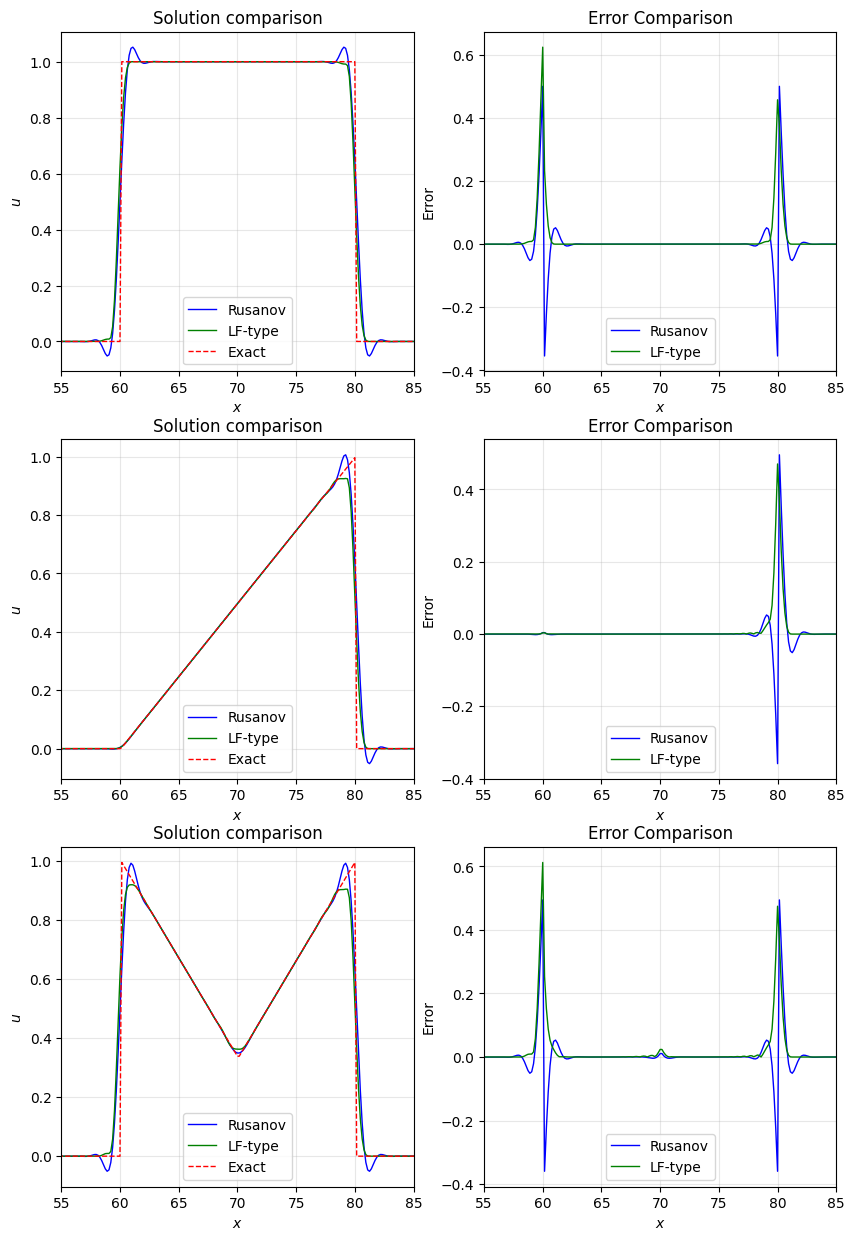

In [ ]:
plt.figure(figsize=(10, 15))

for i, (ic_func, ic_kwargs) in enumerate(
    zip(
        [rectangle,
         left_triangle,
         letter_m,
        #  gaussian_pulse,
         ],
        [{"l1": 10.0, "l2": 30.0},
         {"l1": 10.0, "l2": 30.0},
         {"l1": 10.0, "l2": 30.0},
        #  {"center": 20.0, "width": 5.0},
         ])):
    grid, u, u_exact = advect(
            mlf_with_correction_step,
            ic_func=ic_func,
            ic_kwargs=ic_kwargs,
        )
    grid, u_rusanov, u_exact = advect(
            rusanov_step,
            ic_func=ic_func,
            ic_kwargs=ic_kwargs,
        )

    plt.subplot(3, 2, 2 * i + 1)

    plt.plot(grid, u_rusanov, 'b-', linewidth=1, label='Rusanov')
    plt.plot(grid, u, 'g-', linewidth=1, label='LF-type')
    plt.plot(grid, u_exact, 'r--', linewidth=1, label='Exact')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('$u$')
    plt.title('Solution comparison')
    plt.legend(loc='lower center')
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 2, 2 * i + 2)
    error_rusanov = u_rusanov - u_exact
    error = np.abs(u - u_exact)

    plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Rusanov')
    plt.plot(grid, error, 'g-', linewidth=1, label='LF-type')
    plt.xlabel('$x$')
    plt.xlim(70 - 15, 70 + 15)
    plt.ylabel('Error')
    plt.title('Error Comparison')
    plt.legend(loc='lower center')
    plt.grid(True, alpha=0.3)

plt.show()